In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
import matplotlib.pyplot as plt

In [4]:
## ADDED for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
torch.manual_seed(42)

In [7]:
df = pd.read_csv('/content/fashion-mnist_complete.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df.shape

(70000, 785)

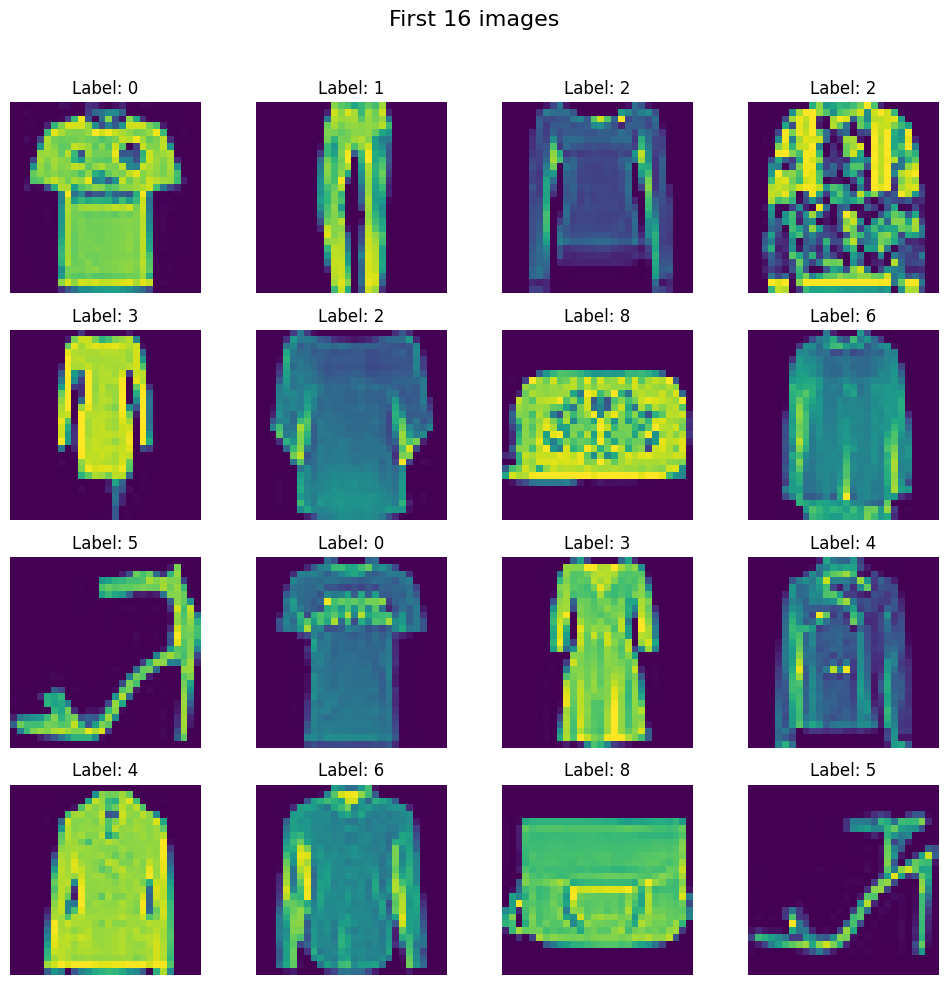

In [9]:
# Create a 4X4 grid of image
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 images", fontsize=16)

# Plot the first 16 iamges form the dataset
for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label: {df.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()
# print(fig)
# print(type(fig))
# print(axes)
# print((axes))

In [14]:
# Train test split
X = df.iloc[:,1:,].values
y = df.iloc[:,0,].values
print((X[0]).shape)

(784,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Feature Scaling
X_train = X_train / 255.0
X_test = X_test / 255.0

In [15]:
# CREATE CustomDataset class
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]

In [16]:
# CREATE TRAIN_DATASET OBJECT
train_dataset = CustomDataset(X_train, y_train)

In [17]:
train_dataset[0]
len(train_dataset)

56000

In [18]:
# CREATE TEST DATASET OBJECT
test_dataset = CustomDataset(X_test, y_test)
len(test_dataset)

14000

In [ ]:
# def CustomDataLoader(dataset, batch_size, shuffle=True):
#   return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [ ]:
# Create the train and test loader

## ADDED for GPU
# batch_size=128, pin_memory = True
# The dataloader has to be moved inside the
# objecive function to hyperparameter tune it as well

In [19]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True, pin_memory = True)

# train_loader

In [24]:
class MyNN(nn.Module):
  def __init__(self, input_features):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),##ip=1*28*28 => 32(1*3*3)=> 32*28*28
        # nn.Conv2d(in_channels=1, out_channels=neurons_per_layer, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),## 32*14*14

        nn.Conv2d(32, 64, kernel_size=3, padding='same'),##ip=32*14*14 => 64(32*3*3)=> 64*14*14
        # nn.Conv2d(in_channels=1, out_channels=neurons_per_layer, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2) ## 64*7*7
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=64*7*7, out_features=128),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(in_features=128, out_features=64),
        nn.ReLU(),
        nn.Dropout(p=0.4),


        nn.Linear(in_features=64, out_features=10)
    )

  def forward(self, x):
    x = self.features(x)
    # x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x


In [25]:
model = MyNN(1)
model.to(device)

#Params init
epochs = 100
learning_rate = 0.1

# optimizer selection
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 1e-4)

# TRAINING LOOP
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    ## Move the data to GPU
    ## ADDED for GPU
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    # Forward pass
    outputs = model(batch_features)
    # print(f"for batch {i}: batch_labels = {batch_labels}")
    # print(f"for batch {i}: outputs = {outputs}")
    loss = criterion(outputs, batch_labels)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss += loss.item()
  avg_epoch_loss = total_epoch_loss/len(train_loader)
  print(f"loss in epoch{epoch} = {avg_epoch_loss}")

loss in epoch0 = 0.5586916653601002
loss in epoch1 = 0.3576580799401623
loss in epoch2 = 0.30390159142752216
loss in epoch3 = 0.2764237007491937
loss in epoch4 = 0.251346323213893
loss in epoch5 = 0.2364606856789491
loss in epoch6 = 0.21627253865542478
loss in epoch7 = 0.20646621887338215
loss in epoch8 = 0.1939009902445965
loss in epoch9 = 0.17814373896886768
loss in epoch10 = 0.17567170670757828
loss in epoch11 = 0.16120997810370574
loss in epoch12 = 0.1569934095847144
loss in epoch13 = 0.14880472823092927
loss in epoch14 = 0.14365211653961166
loss in epoch15 = 0.13234426551944997
loss in epoch16 = 0.12549986102146238
loss in epoch17 = 0.12067914387576928
loss in epoch18 = 0.11481070868909087
loss in epoch19 = 0.11030832225176161
loss in epoch20 = 0.10171728042383853
loss in epoch21 = 0.1011374617446231
loss in epoch22 = 0.10044601065910434
loss in epoch23 = 0.0962968550613958
loss in epoch24 = 0.08786693154557791
loss in epoch25 = 0.08260819942320455
loss in epoch26 = 0.083898552757

In [27]:
# evaluation loop
model.eval()
# EVALUATION CODE for TEST DATA
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    ## Move the data to GPU
    ## ADDED for GPU
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs = model(batch_features)
    _, predicted = torch.max(outputs.data, 1)
      # the _, is ignoring the confidence score, predicted is storing the
      # index of the highest confidence score
    total += batch_labels.size(0)
    correct += (predicted == batch_labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy on the test set: {accuracy:.2f}%")

Accuracy on the test set: 92.97%


In [28]:
# evaluation loop
model.eval()
# EVALUATION CODE for TRAIN DATA
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in train_loader:
    ## Move the data to GPU
    ## ADDED for GPU
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs = model(batch_features)
    _, predicted = torch.max(outputs.data, 1)
      # the _, is ignoring the confidence score, predicted is storing the
      # index of the highest confidence score
    total += batch_labels.size(0)
    correct += (predicted == batch_labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy on the test set: {accuracy:.2f}%")

Accuracy on the test set: 99.93%


In [ ]:
# Building an Objective function

# Ways to improve the acurracy :
    #GPU:
      # used larger dataset
      # created device object from cuda GPU
      # moved model to GPU
      # moved data from dataloader during training and inference to GPU
      # increased batch size during dataloader creation
      # enable the pin memory
          # i.e instead of pager to pin mem directly to pin memory
    # size of dataset,
    # optimizer
    # learning rate
    # epochs
    # weights initialization
    # regularization
    # batch normalization
    # model architecture